In [11]:
import numpy as np
import torch
import polars as pl
import seaborn as sns
from pathlib import Path
from tbparse import SummaryReader
from tem import world

version = "v1"

# directory to save results
base_dir = Path(f"~/Dropbox/work/tem/operators/{version}").expanduser()

fig_dir = base_dir / "figs"
fig_dir.mkdir(exist_ok=True, parents=True)

# mounted uFiles directory with design data
design_dir = Path(f"/Volumes/hamllab/data/beh/Operators/{version}/code/operators/design")

start_subj = 1
n_subj = 20
subjects = [f"{number:03d}" for number in range(start_subj, start_subj + n_subj)]
n_runs = 10

In [2]:
# Set random seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)

env_files = ["../envs/2x3_env1.json", "../envs/2x3_env2.json"]

sim_dir = base_dir / "simulation"
sim_dir.mkdir(exist_ok=True)

study_dir = sim_dir / "study-1"
while study_dir.exists():
    number = int(study_dir.name.split("-")[1])
    study_dir = sim_dir / f"study-{number + 1}"
study_dir.mkdir()

for subject in subjects:
    raw_file = design_dir / f"sub-{subject}" / f"sub-{subject}_task-learning_design.csv"
    raw = pl.read_csv(raw_file)
    trials = raw.filter(
        ~(
            pl.col("trial_type").str.starts_with("practice")
            | pl.col("trial_type").str.contains("instruction")
            | pl.col("trial_type").str.contains("feedback")
        )
    )
    out_dir = study_dir / f"sub-{subject}"
    out_dir.mkdir()
    design_files = [
        out_dir / f"sub-{subject}_graph-{graph}_design.csv" for graph in [1, 2]
    ]
    trials.filter(graph="graph_1").write_csv(design_files[0])
    trials.filter(graph="graph_2").write_csv(design_files[1])

    out_dir.mkdir(exist_ok=True)
    for run in range(1, n_runs + 1):
        tem_model = world.learn_operators(env_files, design_files, out_dir, subject, run)

In [7]:
raw_dfs = []
for subject in subjects:
    number = int(subject)
    if number % 2 == 0:
        condition = "AL"
    else:
        condition = "PI"
    for design in ["0", "1"]:
        reader = SummaryReader(str(study_dir / f"sub-{subject}" / f"design-{design}"))
        raw = (
            pl.DataFrame(reader.scalars)
            .with_columns(
                subject=pl.lit(subject),
                condition=pl.lit(condition),
                design=pl.lit(design),
                run=pl.col("value").cum_count().over(pl.col("step")),
            )
        )
        raw_dfs.append(raw)
df = pl.concat(raw_dfs)

In [8]:
df = df.with_columns(
    pl.col("step").cum_count().over("subject", "run", "design").alias("Trial"),
    pl.col("design").replace({"0": "Initial", "1": "Transfer"}).alias("Graph"),
)

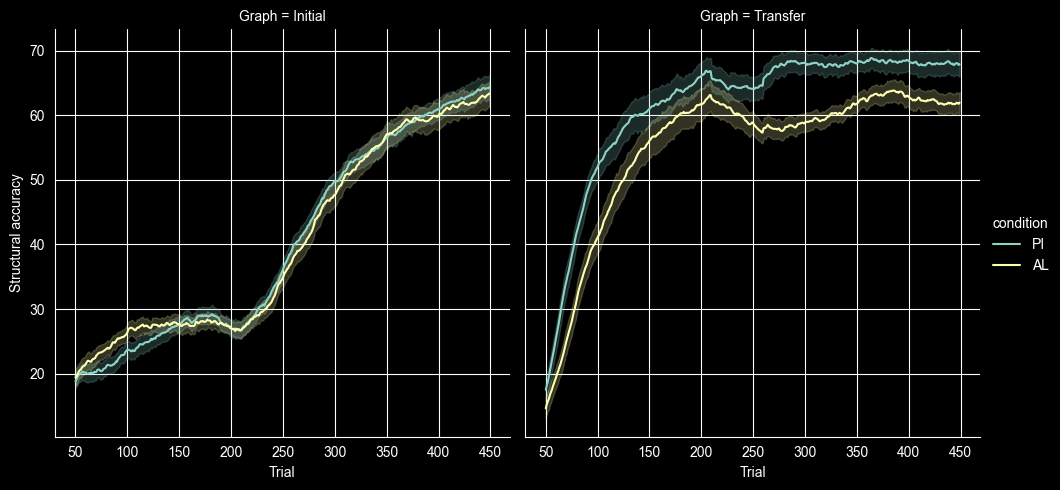

In [13]:
g = sns.relplot(
    (
        df.filter(pl.col("tag") == "Accuracies/g")
        .with_columns(pl.col("value").rolling_mean(window_size=50).over("subject", "run", "Graph"))
    ),
    x="Trial",
    y="value",
    col="Graph",
    kind="line",
    hue="condition",
)
g.set(ylabel="Structural accuracy")
g.savefig(fig_dir / f"learning_{version}_structure.pdf")

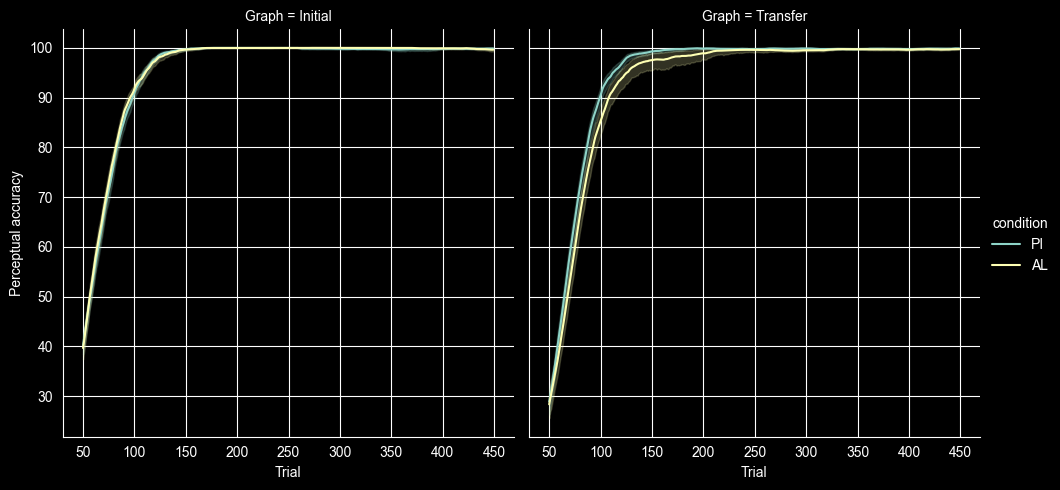

In [12]:
g = sns.relplot(
    (
        df.filter(pl.col("tag") == "Accuracies/p")
        .with_columns(pl.col("value").rolling_mean(window_size=50).over("subject", "run", "Graph"))
    ),
    x="Trial",
    y="value",
    col="Graph",
    kind="line",
    hue="condition",
)
g.set(ylabel="Perceptual accuracy")
g.savefig(fig_dir / f"learning_{version}_perception.pdf")